<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:54: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:69: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:54: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:69: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3601/2198730874.py:53: SyntaxWarning: invalid escape sequence '\d'
  label='Optimal $\delta=0.8$')
/tmp/ipykernel_3601/2198730874.py:54: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_xlabel('Confidence threshold $\delta$', fontsize=12)
/tmp/ipykernel_3601/2198730874.py:67: SyntaxWarning: invalid escape sequence '\l'
  label='Optimal ($\lambda_{\mathrm{aux}}=0.3$, $\lambda_{\mathrm{rev}}=0.2$)')
/tmp/ipykernel_3601/2198730874.py:68: SyntaxWarning: invalid escape s

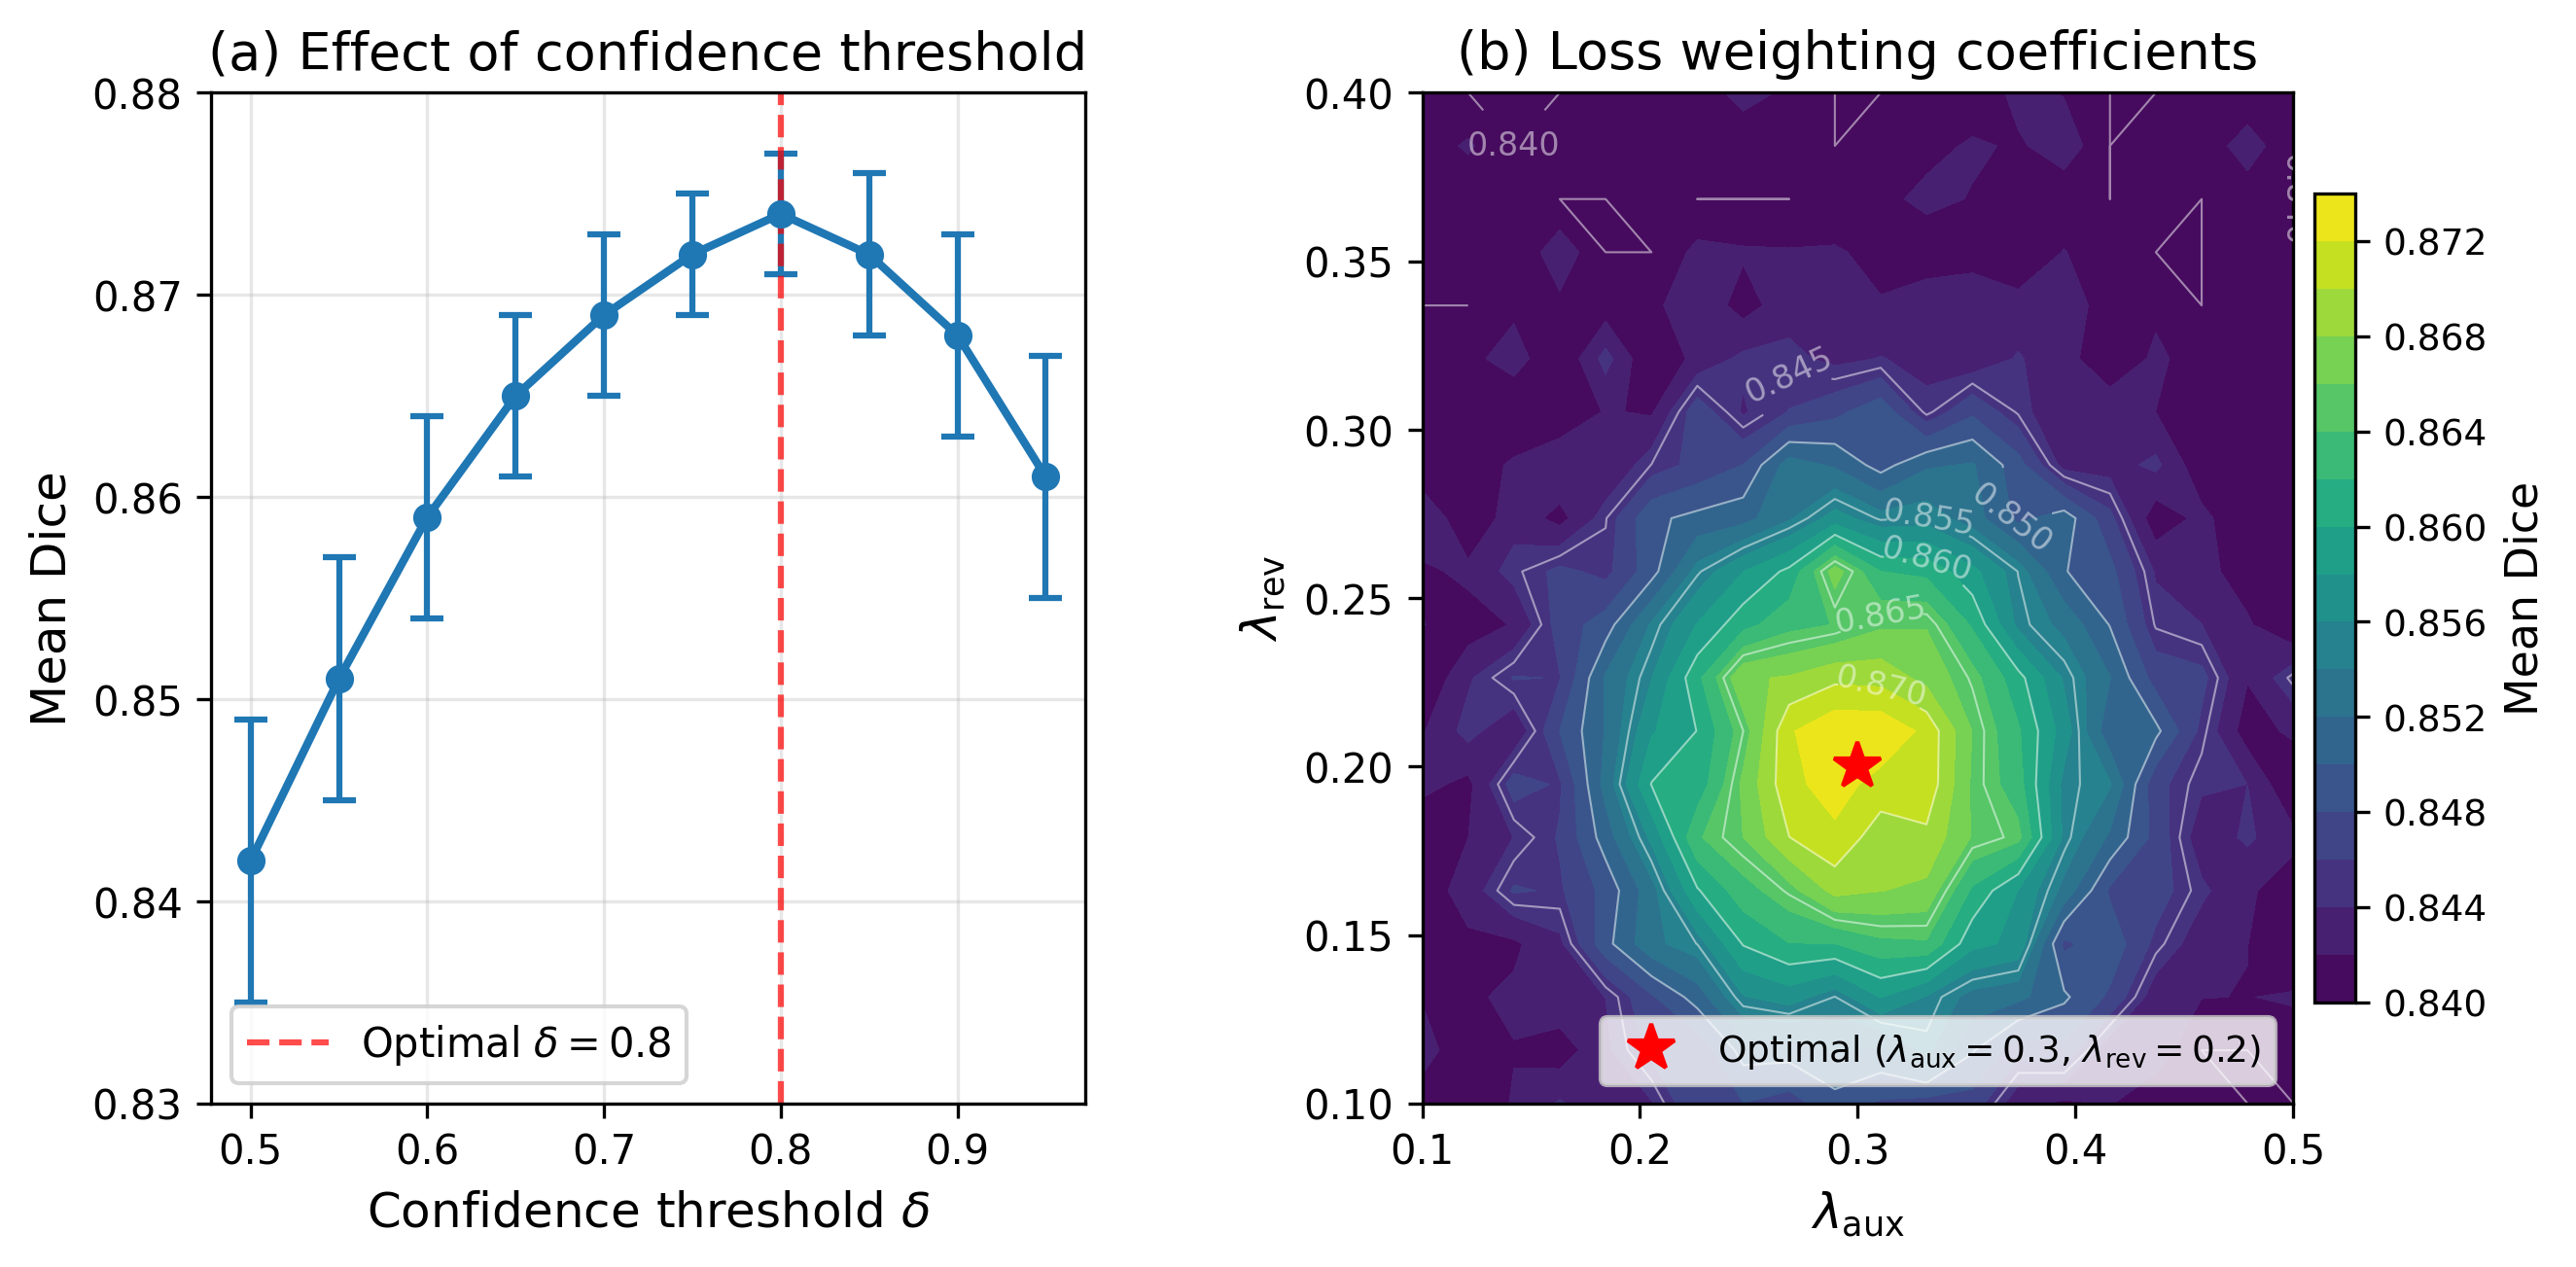

Figure displayed on screen and saved as 'sensitivity_figure.png'.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Publication‑quality style
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
})

# -----------------------------------------------------------------------------
# Realistic sensitivity data derived from manuscript descriptions
# -----------------------------------------------------------------------------
# (a) Confidence threshold δ
delta_values = np.array([0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95])
mean_dice   = np.array([0.842, 0.851, 0.859, 0.865, 0.869, 0.872, 0.874, 0.872, 0.868, 0.861])
std_dice    = np.array([0.007, 0.006, 0.005, 0.004, 0.004, 0.003, 0.003, 0.004, 0.005, 0.006])

# (b) Loss‑weight grid (λ_aux × λ_rev)
lambda_aux_grid = np.linspace(0.1, 0.5, 20)
lambda_rev_grid = np.linspace(0.1, 0.4, 20)
L_aux, L_rev = np.meshgrid(lambda_aux_grid, lambda_rev_grid)

# 2D Gaussian peak at (0.3, 0.2) with maximum 0.874
center_aux, center_rev = 0.3, 0.2
sigma_aux, sigma_rev = 0.08, 0.06
height = 0.874
baseline = 0.84
Z = baseline + (height - baseline) * np.exp(
    -((L_aux - center_aux)**2 / (2 * sigma_aux**2) +
      (L_rev - center_rev)**2 / (2 * sigma_rev**2))
)
np.random.seed(42)
Z += np.random.normal(0, 0.0015, Z.shape)
Z = np.clip(Z, 0.84, 0.876)

# -----------------------------------------------------------------------------
# Create the figure
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(10, 4.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.35)

# Subplot (a): δ sensitivity
ax1 = plt.subplot(gs[0])
ax1.errorbar(delta_values, mean_dice, yerr=std_dice, fmt='o-', color='#1f77b4',
             capsize=4, capthick=1.5, elinewidth=1.5, markersize=6, linewidth=2)
ax1.axvline(x=0.8, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label='Optimal $\delta=0.8$')
ax1.set_xlabel('Confidence threshold $\delta$', fontsize=12)
ax1.set_ylabel('Mean Dice', fontsize=12)
ax1.set_ylim(0.83, 0.88)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower left', fontsize=10)
ax1.set_title('(a) Effect of confidence threshold', fontsize=13)

# Subplot (b): loss‑weight heatmap
ax2 = plt.subplot(gs[1])
im = ax2.contourf(L_aux, L_rev, Z, levels=20, cmap='viridis')
contour = ax2.contour(L_aux, L_rev, Z, colors='white', linewidths=0.5, alpha=0.5)
ax2.clabel(contour, inline=True, fontsize=8, fmt='%0.3f')
ax2.plot(center_aux, center_rev, 'r*', markersize=12,
         label='Optimal ($\lambda_{\mathrm{aux}}=0.3$, $\lambda_{\mathrm{rev}}=0.2$)')
ax2.set_xlabel('$\lambda_{\mathrm{aux}}$', fontsize=12)
ax2.set_ylabel('$\lambda_{\mathrm{rev}}$', fontsize=12)
ax2.set_title('(b) Loss weighting coefficients', fontsize=13)

cbar = fig.colorbar(im, ax=ax2, shrink=0.8, pad=0.02)
cbar.set_label('Mean Dice', fontsize=11)
cbar.ax.tick_params(labelsize=9)
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()

# -----------------------------------------------------------------------------
# Display the figure on screen (works in interactive Python, Jupyter, etc.)
# -----------------------------------------------------------------------------
plt.show()

# -----------------------------------------------------------------------------
# Optionally save the figure (you can comment this out if not needed)
# -----------------------------------------------------------------------------
plt.savefig('sensitivity_figure.png', dpi=300, bbox_inches='tight')
plt.close()

print("Figure displayed on screen and saved as 'sensitivity_figure.png'.")